Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.3466 - val_loss: 0.1666
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 0.1569 - val_loss: 0.1336
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.1312 - val_loss: 0.1207
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.1204 - val_loss: 0.1136
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.1140 - val_loss: 0.1092
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.1097 - val_loss: 0.1058
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.1064 - val_loss: 0.1034
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1045 - val_loss: 0.1026
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1031 - val_loss: 0.1009
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1009 - val_loss: 0.0988
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0995 - val_loss: 0.0974
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━

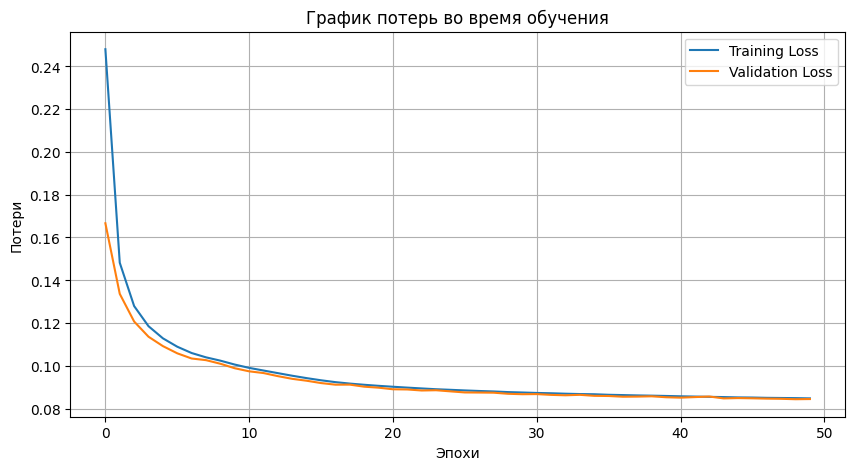

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


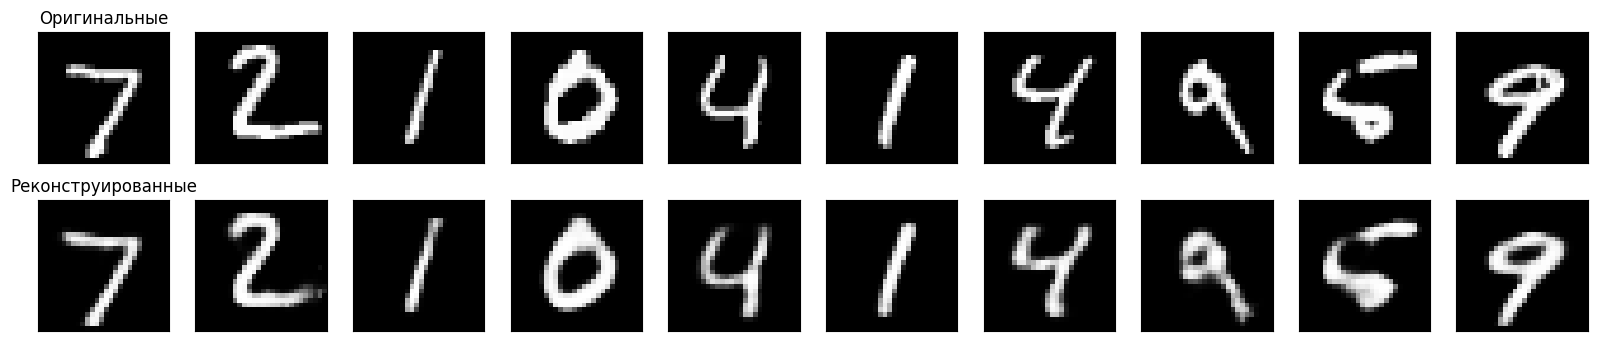

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


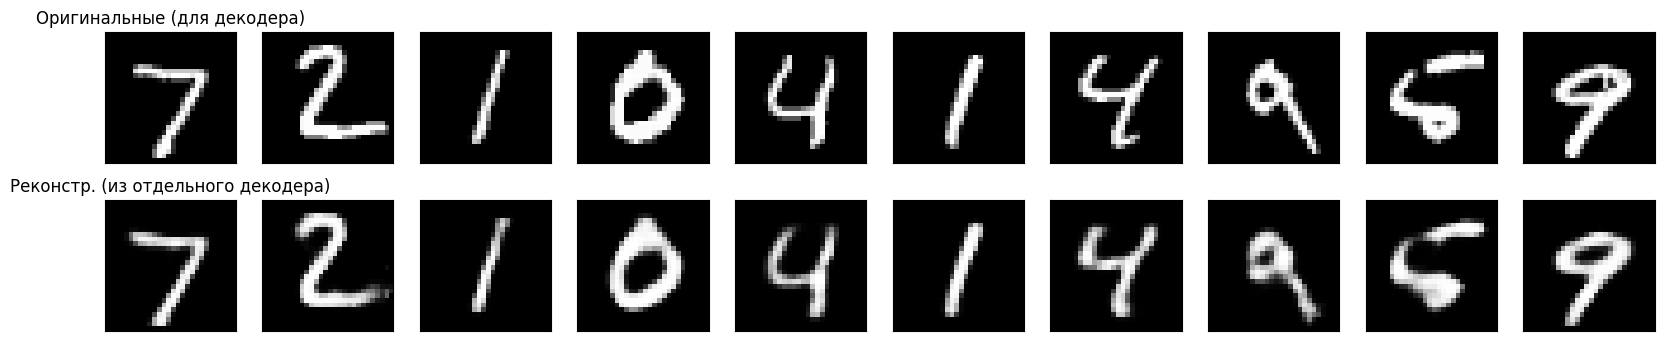

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
encoding_dim = 32


input_img = Input(shape=(784,)) # 28*28 = 784
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)
autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded)
encoded_input = Input(shape=(encoding_dim,))
decoder_layer1 = autoencoder.layers[-3]
decoder_layer2 = autoencoder.layers[-2]
decoder_layer3 = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer3(decoder_layer2(decoder_layer1(encoded_input))))
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history = autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('График потерь во время обучения')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()
plt.grid(True)
plt.show()


decoded_imgs = autoencoder.predict(x_test)


n = 10  # Количество изображений для отображения
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Оригинальные")


    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Реконструированные")
plt.show()


encoded_imgs = encoder.predict(x_test)
decoded_from_encoded = decoder.predict(encoded_imgs)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Оригинальные (для декодера)")
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_from_encoded[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Реконстр. (из отдельного декодера)")
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.3337 - val_loss: 0.1557
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.1468 - val_loss: 0.1254
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.1238 - val_loss: 0.1153
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.1147 - val_loss: 0.1088
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1093 - val_loss: 0.1047
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1053 - val_loss: 0.1019
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1019 - val_loss: 0.0983
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0988 - val_loss: 0.0963
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0968 - val_loss: 0.0945
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0951 - val_loss: 0.0930
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0936 - val_loss: 0.0916
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━

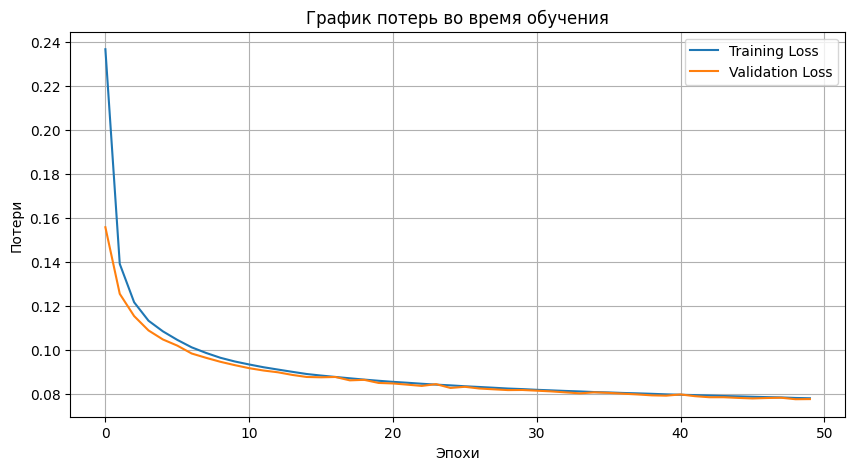

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


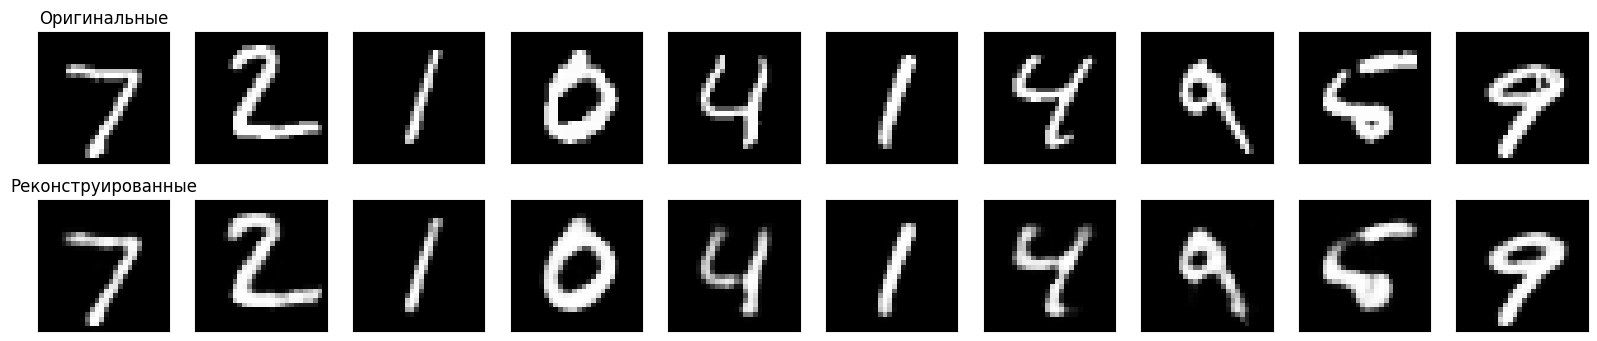

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


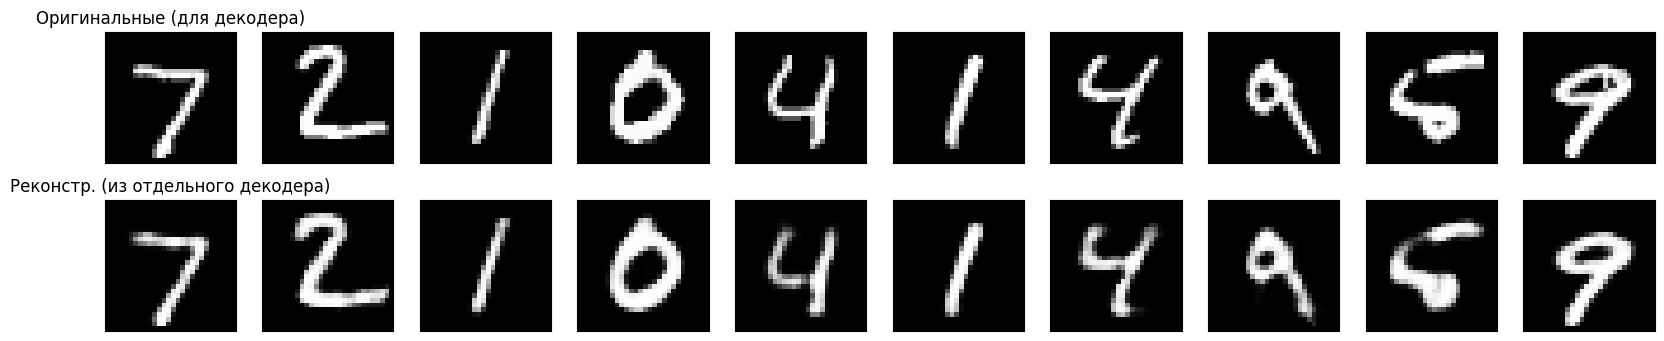

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
encoding_dim =  128


input_img = Input(shape=(784,)) # 28*28 = 784
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)
autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded)
encoded_input = Input(shape=(encoding_dim,))
decoder_layer1 = autoencoder.layers[-3]
decoder_layer2 = autoencoder.layers[-2]
decoder_layer3 = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer3(decoder_layer2(decoder_layer1(encoded_input))))
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history = autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('График потерь во время обучения')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()
plt.grid(True)
plt.show()


decoded_imgs = autoencoder.predict(x_test)


n = 10  # Количество изображений для отображения
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Оригинальные")
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Реконструированные")
plt.show()


encoded_imgs = encoder.predict(x_test)
decoded_from_encoded = decoder.predict(encoded_imgs)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Оригинальные (для декодера)")


    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_from_encoded[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Реконстр. (из отдельного декодера)")
plt.show()